<a href="https://github.com/luisfrancs/metal_workload_eda_nestedcv/blob/main/NESTED_CV_RF_WORKER_TARGET_GROPEDkFOLD_EDA_REFACTOR_TURIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assessing Mental Workload in Office Environments using Electro dermal activity (EDA)
## 01HXDIU - Machine Learning in Healthcare: From Theory to Practice
### Author: Phd Luis Sigcha
### Date: 19/05/2026

### Download data and utils functions

In [1]:
# 1. Clone the repository
!git clone https://github.com/luisfrancs/metal_workload_eda_nestedcv

# 2. Move into the project directory
%cd metal_workload_eda_nestedcv

Cloning into 'metal_workload_eda_nestedcv'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 20 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 1.50 MiB | 10.67 MiB/s, done.
Resolving deltas: 100% (1/1), done.


/content/metal_workload_eda_nestedcv


### Import required libraries.


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import utils, training_ML_binary, metrics_ML_binary

In [7]:
pd.set_option('display.max_colwidth', None)  # Don't truncate text within cells

### DATA READING

In [8]:
UN_features = np.load('EDA_TEST_FEATURES/UNIVERSE_features_ss0.npy')
UN_y = np.load('EDA_TEST_FEATURES/UNIVERSE_y_ss0.npy').flatten()
UN_idLOSO = np.load('EDA_TEST_FEATURES/UNIVERSE_idLOSO_ss0.npy').flatten()

In [9]:
UN_features.shape

(2798, 30)

In [10]:
WK_features = np.load('EDA_TEST_FEATURES/WORKER_features_EDA_4.01.npy')
WK_y = np.load('EDA_TEST_FEATURES/WORKER_y_EDA_4.01.npy').flatten()
WK_idLOSO = np.load('EDA_TEST_FEATURES/WORKER_idLOSO_EDA_4.01.npy').flatten()

In [11]:
WK_features.shape

(2453, 30)

# ASSIGN TARGET and SOURCE

In [12]:
target_df="WORKER"; #"UNIVERSE" "WORKER

In [13]:
if target_df == "WORKER":
    print("Running WORKER as TARGET")
    X_target=WK_features; y_target=WK_y; idLOSO_target=WK_idLOSO
    X_source=UN_features; y_source=UN_y; idLOSO_source=UN_idLOSO
    #n_splits=10#5
elif target_df == "UNIVERSE":
    print("Running UNIVERSE as TARGET")
    X_target=UN_features; y_target=UN_y; idLOSO_target=UN_idLOSO
    X_source=WK_features; y_source=WK_y; idLOSO_source=WK_idLOSO
    #n_splits=10
else:
    raise ValueError("target_df must be either 'WORKER' or 'UNIVERSE'")

Running WORKER as TARGET


In [14]:
'''NESTED CV SPLIT PARAMETERS'''
n_splits_outer=10
n_splits_inner=5

In [15]:
from utils_nested import (evaluate_model, evaluate_best_model, mean_sd_table, get_metrics_df,
                            nested_grouped_training_pipeline)

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest,f_classif

In [17]:
from sklearn.decomposition import PCA

In [18]:
from sklearn.pipeline import Pipeline
#from xgboost import XGBClassifier

## Parameter Grids

In [19]:
baseline_param_grid = {
    "clf__n_estimators": [100, 150, 200],
    "clf__max_depth": [3, 5],
    "clf__min_samples_split": [20, 25, 30]}

In [20]:
# Generate param grid for ADAPT METHODS
sa_param_grid = sa_param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [3, 5],
    "min_samples_split": [20, 25, 30]}

## Baseline

In [21]:
def baseline_pipeline_factory():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        #("pca", PCA(n_components=15)), reduce the fscire to 0.56
        ("clf", RandomForestClassifier())    ])
    return pipe

In [ ]:
results_bs, models_bs, metrics_source_bs, metrics_target_bs, target_split_bs = nested_grouped_training_pipeline(
    X_source, y_source, idLOSO_source,
    X_target, y_target, idLOSO_target,
    pipeline_factory=baseline_pipeline_factory,
    param_grid=baseline_param_grid,
    n_splits_outer=n_splits_outer,    n_splits_inner=n_splits_inner,   target_test_size=0.3)

Target alignment samples: 1672
Target test samples: 781
Source metrics:
roc_auc= 1.0
Best EER Threshold= 0.5780598107459626   EER= 0.0
Y-shape  (272,)
Optimal threshold : 0.578060


accuracy:  1.0
[[ 90   0]
 [  0 182]]
 
sensitivity:  1.0
specificity:  1.0
precision:  1.0
F1-score:  1.0
AUC:  1.0
AUC-PR:  0.9999999999999999

Fold 0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        90
           1       1.00      1.00      1.00       182

    accuracy                           1.00       272
   macro avg       1.00      1.00      1.00       272
weighted avg       1.00      1.00      1.00       272

Target metrics:
roc_auc= 0.6323790662174966
Best EER Threshold= 0.8227030421558608   EER= 38.858695652173914
Y-shape  (781,)
Optimal threshold : 0.822703


accuracy:  0.6120358514724712
[[225 143]
 [160 253]]
 
sensitivity:  0.612590799031477
specificity:  0.6114130434782609
precision:  0.6388888888888888
F1-score:  0.6254635352286774
A

In [ ]:
results_bs['gap_fscore']=results_bs['source_f1']-results_bs['target_f1']
results_bs['gap_accuracy']=results_bs['source_acc']-results_bs['target_acc']

In [ ]:
results_bs

,fold,best_params,source_f1,target_f1,source_acc,target_acc,gap_fscore,gap_accuracy
0,0,"{'clf__max_depth': 5, 'clf__min_samples_split': 25, 'clf__n_estimators': 150}",0.966480,0.622991,0.955882,0.609475,0.343489,0.346407
1,1,"{'clf__max_depth': 3, 'clf__min_samples_split': 30, 'clf__n_estimators': 100}",0.903409,0.616337,0.875000,0.603073,0.287072,0.271927
2,2,"{'clf__max_depth': 3, 'clf__min_samples_split': 30, 'clf__n_estimators': 100}",0.819767,0.613861,0.772059,0.600512,0.205906,0.171547
3,3,"{'clf__max_depth': 5, 'clf__min_samples_split': 25, 'clf__n_estimators': 200}",0.938202,0.616337,0.919118,0.603073,0.321866,0.316045
4,4,"{'clf__max_depth': 3, 'clf__min_samples_split': 30, 'clf__n_estimators': 100}",0.759644,0.606436,0.702206,0.592830,0.153208,0.109376
5,5,"{'clf__max_depth': 3, 'clf__min_samples_split': 30, 'clf__n_estimators': 100}",0.608150,0.605459,0.540441,0.592830,0.002691,-0.052389
6,6,"{'clf__max_depth': 5, 'clf__min_samples_split': 20, 'clf__n_estimators': 100}",0.948864,0.646914,0.933824,0.633803,0.301950,0.300021
7,7,"{'clf__max_depth': 5, 'clf__min_samples_split': 20, 'clf__n_estimators': 100}",0.862069,0.635352,0.823529,0.622279,0.226717,0.201250
8,8,"{'clf__max_depth': 3, 'clf__min_samples_split': 30, 'clf__n_estimators': 150}",0.951567,0.607187,0.936330,0.594110,0.344380,0.342219
9,9,"{'clf__max_depth': 3, 'clf__min_samples_split': 25, 'clf__n_estimators': 100}",0.784689,0.611386,0.746479,0.597951,0.173303,0.148528


In [ ]:
def get_best_model_summary(results, models, X_target, y_target, metrics_source, metrics_target,target_split_idx):
    '''Print results and generate data for further evaluation'''
    best_index = results['source_f1'].idxmax()
    print('Best model index', best_index)
    target_test_idx=target_split_idx['test_idx']#get target test idx
    best_model = models[best_index]
    _, best_metrics, probas = evaluate_best_model(best_model, best_index, X_target[target_test_idx], y_target[target_test_idx])
    target_metrics_summary = get_metrics_df(best_metrics)
    source_metrics_NESTED_summary = mean_sd_table( pd.DataFrame(metrics_source), exclude_cols=['fold'], decimals=3 )
    target_metrics_NESTED_summary = mean_sd_table( pd.DataFrame(metrics_target), exclude_cols=['fold'], decimals=3 )
    df_final = pd.concat([source_metrics_NESTED_summary, target_metrics_NESTED_summary], #target_metrics_summary
        keys=['Source Nested CV', 'Target Nest CV',] ) #'Target_test',
    if 'balanced_accuracy' in df_final.columns:
        df_final.drop(columns=['balanced_accuracy'], inplace=True)
    return df_final, best_metrics, probas,best_model

### RESULTS SUMMARY

In [ ]:
df_final_bs, best_metrics_bs, probas_bs, best_model_bs =get_best_model_summary(results_bs, models_bs, X_target, y_target,
                                                                               metrics_source_bs, metrics_target_bs, target_split_bs)
df_final_bs

Best model index 0
roc_auc= 0.6347279976839667
Best EER Threshold= 0.8085152957549656   EER= 39.130434782608695
Y-shape  (781,)
Optimal threshold : 0.808515


accuracy:  0.6094750320102432
[[224 144]
 [161 252]]
 
sensitivity:  0.6101694915254238
specificity:  0.6086956521739131
precision:  0.6363636363636364
F1-score:  0.622991347342398
AUC:  0.6347279976839667
AUC-PR:  0.6225492086415944


,,accuracy,sensitivity,specificity,precision,macro_f1,AUC,AUC_PR
Source Nested CV,0,0.820 (0.132),0.818 (0.132),0.825 (0.133),0.896 (0.088),0.854 (0.114),0.847 (0.151),0.854 (0.114)
Target Nest CV,0,0.605 (0.014),0.605 (0.014),0.605 (0.013),0.632 (0.013),0.618 (0.013),0.634 (0.014),0.618 (0.013)


In [ ]:
from datetime import datetime
import joblib

def save_sklearn_model(model, metric):
    m_date = datetime.today().strftime('%Y-%m-%d_%H-%M-%S')
    asign_name = ('MODEL_RF_ADAPT_SA_optimCROSS_WIND-1min' + m_date + '_f1score_' + str(np.round(metric, decimals=3)) + '.joblib'    )
    joblib.dump(model, asign_name)
    print('saved:', asign_name)

In [ ]:
best_fscore_metric=best_metrics_bs[4]# 4= 'macro_f1'
#save_sklearn_model(best_model, best_fscore_metric)

In [ ]:
from utils_plot import plot_multiple_histograms, plot_all_subject_sequences

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


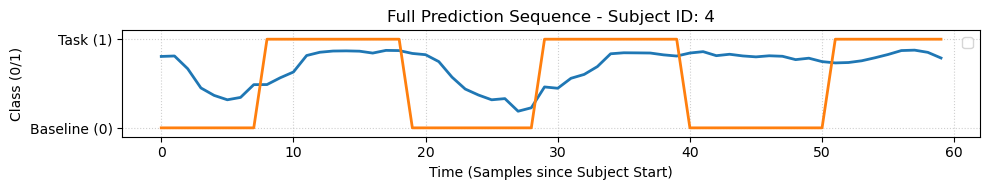

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


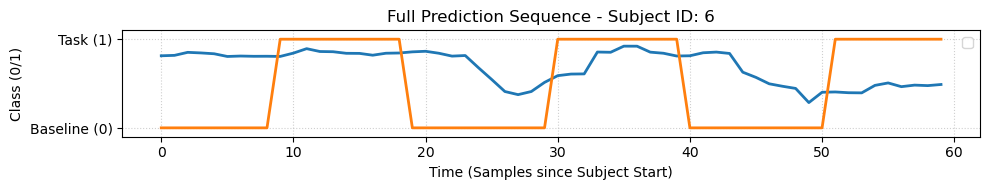

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


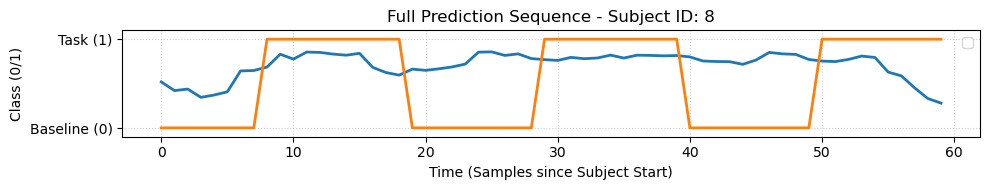

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


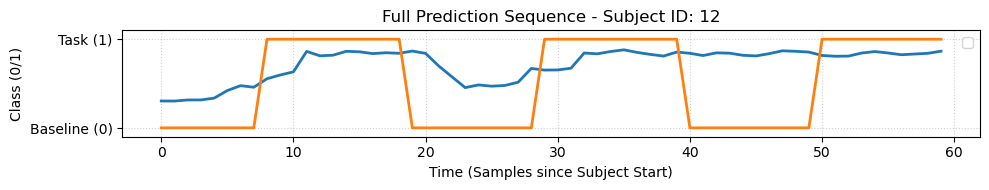

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


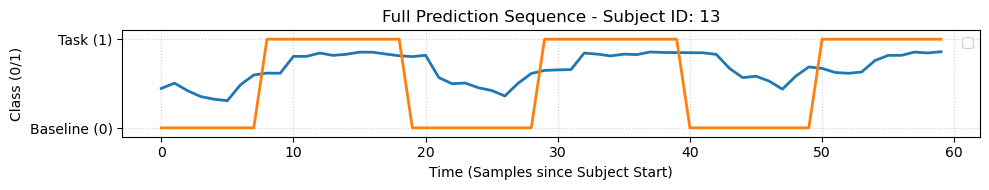

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


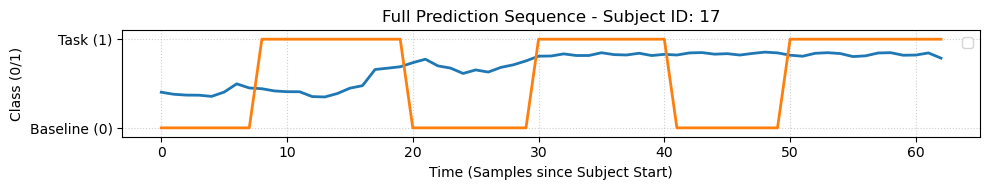

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


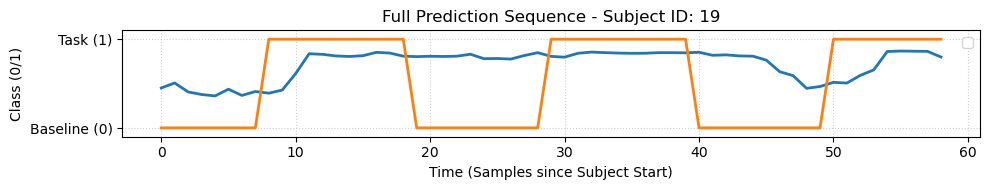

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


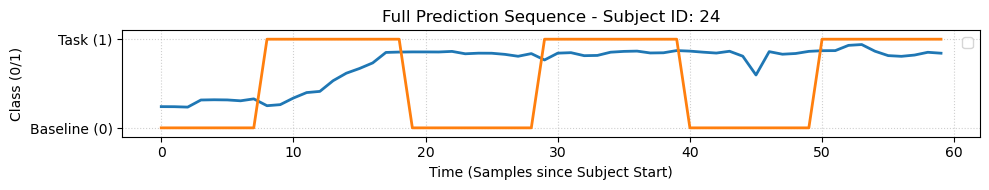

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


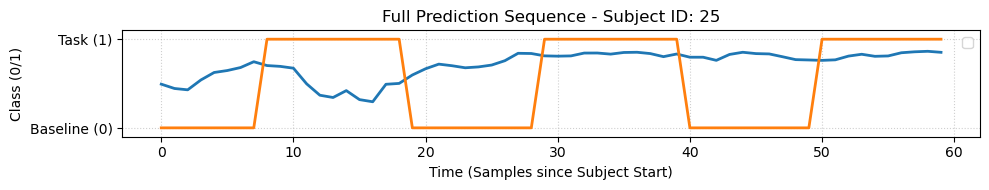

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


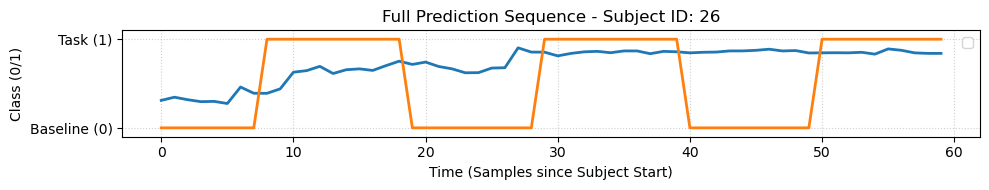

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


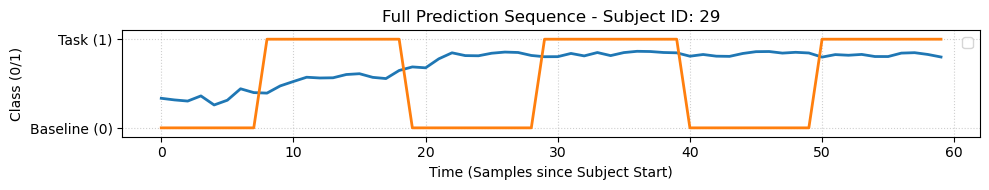

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


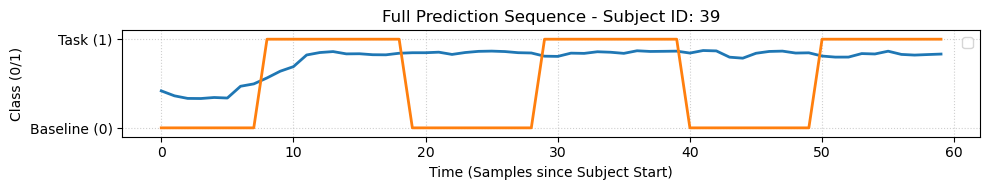

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


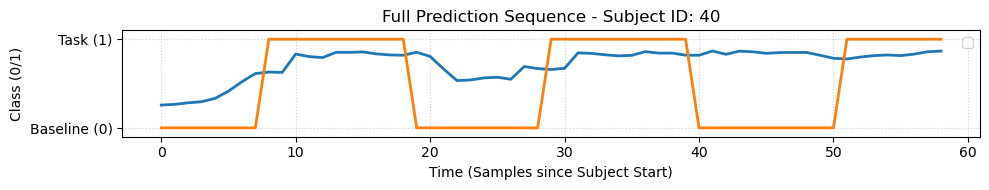

In [ ]:
plot_all_subject_sequences(idLOSO_target[target_split_bs['test_idx']], y_target[target_split_bs['test_idx']], probas_bs[:,1]) #smoothed_preds

In [ ]:
from scipy.signal import medfilt
window_size = 5
smoothed_preds = medfilt(probas_bs[:,1], kernel_size=window_size)

([<matplotlib.axis.YTick at 0x1661a7340>,
 [Text(0, 0, '0'), Text(0, 1, '1')])

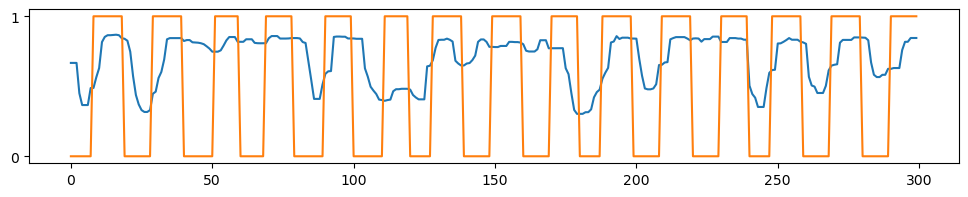

In [ ]:
plt.figure(figsize=(12, 2))
plt.plot(smoothed_preds[0:300])
plt.plot(y_target[target_split_bs['test_idx']][0:300])
plt.yticks([0, 1])

## Feature Importance (Impurity-Based)

In [ ]:
# Get indices of selected features
columns=['eda_peaks', 'scr_mean', 'scr_std', 'scr_max', 'scr_min', 'scr_range','scr_kurtosis', 'scr_skew', 'scr_momentum', 'scr_activity',
       'scr_complexity', 'scr_mobility', 'scr_rms', 'scr_acr_length','scr_integral', 'scr_average_power', 'scr_f1sc', 'scr_f2sc', 'scr_f3sc',
       'scr_Energy', 'scr_Entropy', 'scr_max_freq', 'scl_mean', 'scl_std','scl_max', 'scl_min', 'scl_range', 'scl_kurtosis', 'scl_skew',
       'scl_momentum'] # all original columns


In [ ]:
best_model_bs

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(max_depth=5, min_samples_split=25,
                                        n_estimators=150))])

In [ ]:
importances = best_model_bs.named_steps['clf'].feature_importances_
feature_importance = pd.Series(importances, index=columns).sort_values(ascending=False)
print(feature_importance)

scl_min              0.215757
scl_mean             0.165312
scl_max              0.144298
scr_std              0.036103
scr_rms              0.034061
scr_mobility         0.032803
scl_range            0.031808
scl_std              0.031319
scr_activity         0.030352
scl_momentum         0.030239
scr_average_power    0.029166
eda_peaks            0.028707
scr_momentum         0.027215
scr_integral         0.022978
scr_min              0.021814
scr_range            0.020855
scr_max              0.015088
scr_acr_length       0.014647
scr_Entropy          0.013183
scl_skew             0.009432
scl_kurtosis         0.009274
scr_complexity       0.008033
scr_kurtosis         0.007919
scr_f2sc             0.005322
scr_skew             0.004255
scr_Energy           0.003542
scr_f3sc             0.002891
scr_f1sc             0.002405
scr_mean             0.000626
scr_max_freq         0.000595
dtype: float64
